In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.nn.modules.pooling import MaxPool2d
from torch.nn.modules.activation import ReLU

In [4]:
import zipfile
import os
zip_ref = zipfile.ZipFile('/content/PlantVillage.zip', 'r')
zip_ref.extractall('/content/')
zip_ref.close()

# Assuming the unzipped folder will be named 'PlantVillage'
dataset_root = '/content/PlantVillage'


In [13]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [14]:
#Load Dataset
dataset=datasets.ImageFolder(
    root=dataset_root,
    transform=transoform
)


In [15]:
class_name=dataset.classes
class_name

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [23]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

In [24]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=True)

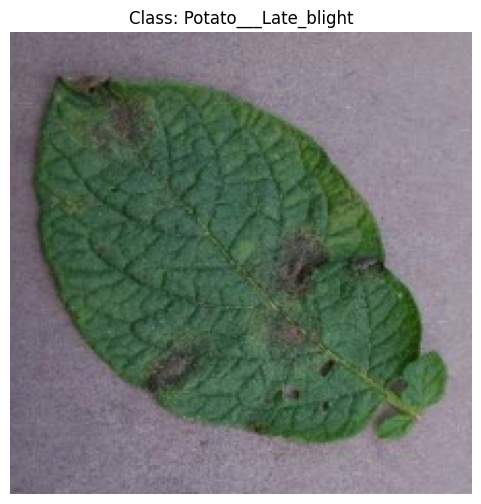

In [25]:
import numpy as np
import matplotlib.pyplot as plt

for images, labels in train_loader:
    image = images[0] # Get the first image from the batch
    label = labels[0] # Get the first label from the batch
    break # Exit after getting the first item

mean = np.array([0.5, 0.5, 0.5])
std = np.array([0.5, 0.5, 0.5])
unnormalized_image = image.numpy().transpose((1, 2, 0))
unnormalized_image = (unnormalized_image * std) + mean
unnormalized_image = np.clip(unnormalized_image, 0, 1)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(unnormalized_image)
plt.title(f"Class: {class_name[label]}")
plt.axis('off')
plt.show()

In [22]:
print(f"Image dimensions: {image.shape}")

Image dimensions: torch.Size([3, 224, 224])


In [27]:
import torchvision.models as models
import torch.nn as nn
model = models.resnet50(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features,3)

In [28]:
print(num_features)

2048


In [9]:
# #Design Model
# class CNN(nn.Module):
#   def __init__(self):
#     super(CNN,self).__init__()

#     self.conv_layer=nn.Sequential(
#         nn.Conv2d(3, 32, 3,padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(2,2),
#         #2nd layer
#         nn.Conv2d(32,64,3,padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(2,2),

#         #3rd
#         nn.Conv2d(64,128,3,padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(2,2),

#     )
#     self.fc_layer=nn.Sequential(
#         nn.Linear(100352,512),
#         nn.ReLU(),
#         nn.Linear(512,3),
#     )
#   def forward(self,x):
#     x=self.conv_layer(x)
#     x=x.view(x.size(0),-1) #flatting
#     x=self.fc_layer(x)
#     return x

In [30]:

criterian=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [31]:
epochs=10
for epoch in range(epochs):
  for image,label in train_loader:
    output=model(image)
    loss=criterian(output,label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  print("Epoch:",epoch,"Loss:",loss.item())


Epoch: 0 Loss: 0.05194084718823433
Epoch: 1 Loss: 0.17137204110622406
Epoch: 2 Loss: 9.595668234396726e-05
Epoch: 3 Loss: 0.6085516810417175
Epoch: 4 Loss: 0.47431084513664246
Epoch: 5 Loss: 3.5762775496550603e-07
Epoch: 6 Loss: 8.344643447344424e-07
Epoch: 7 Loss: 0.0
Epoch: 8 Loss: 0.001147667528130114
Epoch: 9 Loss: 0.0


In [32]:
correct = 0
total = 0

with torch.no_grad():

    for images,labels in test_loader:

        outputs = model(images)
        _,predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:",100*correct/total)

Accuracy: 98.76543209876543


In [33]:
torch.save(model.state_dict(), "potato_disease_model.pth")